In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from scipy.stats import chisquare
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import statsmodels.api as sm

In [2]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
# Drop irrelevant columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Convert categorical variables
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


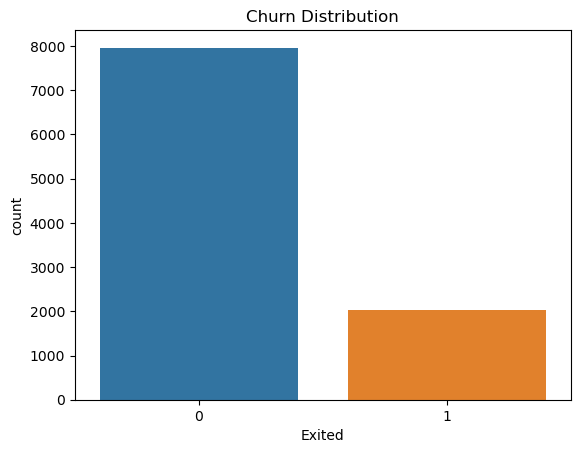

In [6]:
df.describe()

# Churn distribution
df['Exited'].value_counts()

sns.countplot(x='Exited', data=df)
plt.title("Churn Distribution")
plt.show()

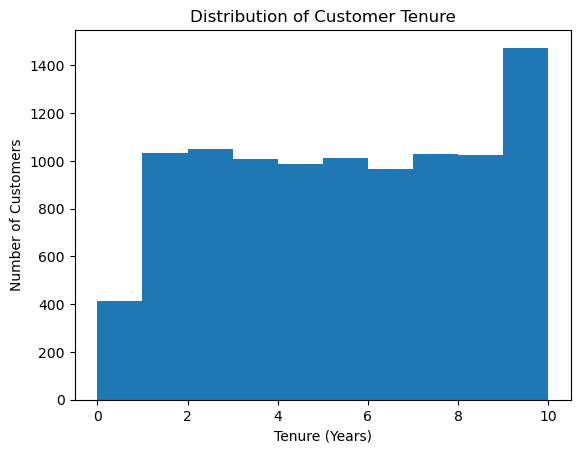

In [7]:
# Plot histogram for tenure
plt.figure()
plt.hist(df['Tenure'], bins=10)

# Labels and title
plt.xlabel('Tenure (Years)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Tenure')

# Show plot
plt.show()

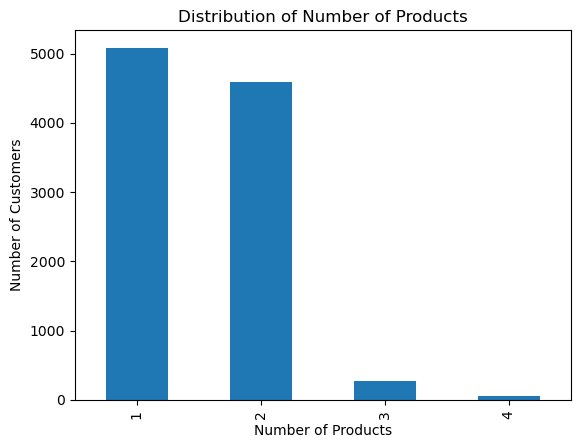

In [8]:
# Count frequency of number of products
product_counts = df['NumOfProducts'].value_counts().sort_index()

# Plot bar chart
plt.figure()
product_counts.plot(kind='bar')

# Labels and title
plt.xlabel('Number of Products')
plt.ylabel('Number of Customers')
plt.title('Distribution of Number of Products')

# Show plot
plt.show()

In [9]:
# Select financial variables
financial_cols = ['CreditScore', 'Balance', 'EstimatedSalary']

# Compute mean and standard deviation
financial_stats = df[financial_cols].agg(['mean', 'std']).T

# Rename columns for clarity
financial_stats.columns = ['Mean', 'Standard Deviation']

# Display results
print(financial_stats)

                          Mean  Standard Deviation
CreditScore         650.528800           96.653299
Balance           76485.889288        62397.405202
EstimatedSalary  100090.239881        57510.492818


In [17]:
# Count churn distribution
churn_counts = df['Exited'].value_counts()

print("Observed counts:")
print(churn_counts)

# Expected distribution (equal split assumption)
expected = [len(df)/2, len(df)/2]

# Chi-square goodness-of-fit test
chi_stat, p_value = chisquare(f_obs=churn_counts.values, f_exp=expected)

print("\nChi-square Statistic:", chi_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Result: Significant difference between churn and retention (p < 0.05)")
else:
    print("Result: No significant difference")

Observed counts:
Exited
0    7963
1    2037
Name: count, dtype: int64

Chi-square Statistic: 3511.7476
p-value: 0.0
Result: Significant difference between churn and retention (p < 0.05)


In [18]:
# Select relevant variables
cols = ['Exited', 'Tenure', 'NumOfProducts']

# Compute correlation matrix
corr_matrix = df[cols].corr()

# Extract churn correlations only
churn_corr = corr_matrix['Exited'].sort_values()

print("Correlation with Churn:\n")
print(churn_corr)

Correlation with Churn:

NumOfProducts   -0.047820
Tenure          -0.014001
Exited           1.000000
Name: Exited, dtype: float64


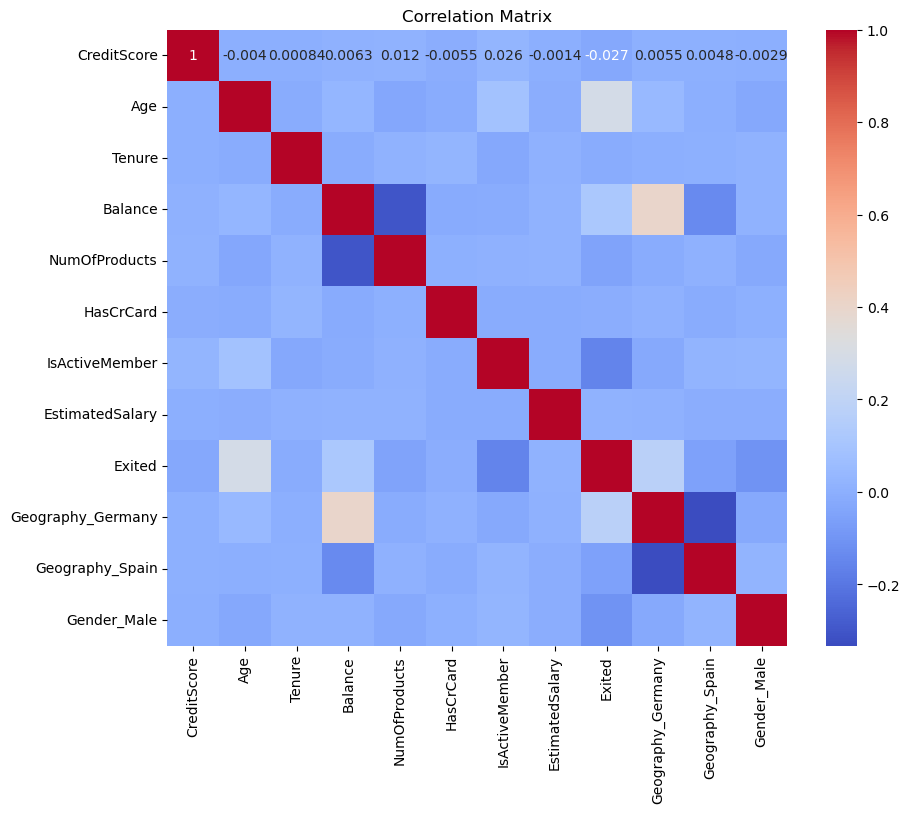

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [11]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.811

Confusion Matrix:
 [[1543   64]
 [ 314   79]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [16]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
1,Age,0.754217
8,Geography_Germany,0.337190
3,Balance,0.161139
9,Geography_Spain,0.038960
7,EstimatedSalary,0.015744
5,HasCrCard,-0.010236
2,Tenure,-0.042637
4,NumOfProducts,-0.060278
0,CreditScore,-0.067683
10,Gender_Male,-0.264718
